In [10]:
import pandas as pd

df = pd.read_csv("downloads/MSFT.csv")

#Parse the date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

#Dropping rows with missing date
df = df.dropna(subset=["Date"])

#Sort by date
df = df.sort_values("Date")

#Set date as index
df = df.set_index("Date")

#Clean column names
df.columns = df.columns.str.strip()

#Calculate returns
df["Return"] = df["Close"].pct_change()
df = df.dropna(subset=["Return"])

#Mean, variance and std
mean_ret = df["Return"].mean()
var_ret = df["Return"].var()
std_ret = df["Return"].std()

df["Return"].agg(["mean", "var", "std"])

mean    0.001115
var     0.000455
std     0.021330
Name: Return, dtype: float64

Text(0, 0.5, 'Growth (x times the original)')

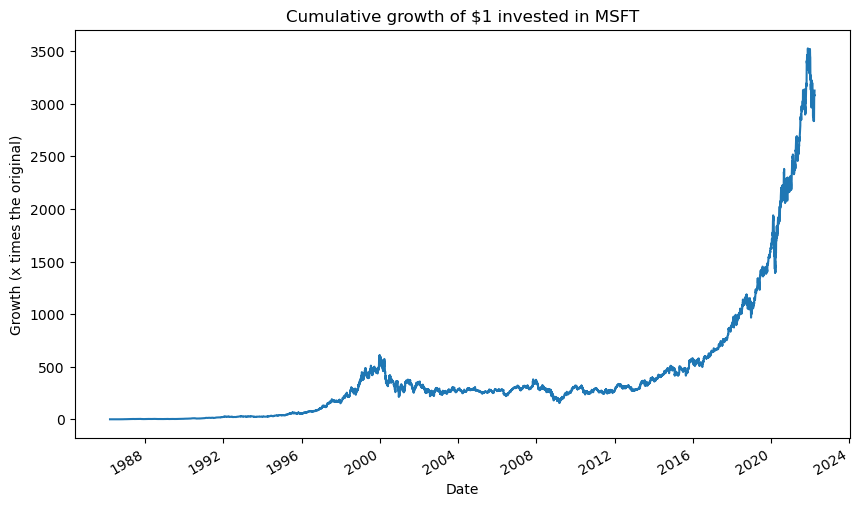

In [14]:
#Cummulative returns
df["Cumulative"] = (1 + df["Return"]).cumprod() - 1

ax = df["Cumulative"].plot(figsize=(10, 6))
ax.set_title("Cumulative growth of $1 invested in MSFT")
ax.set_xlabel("Date")
ax.set_ylabel("Growth (x times the original)")